In [41]:
from pathlib import Path
import yaml

PROJECT_ROOT = Path.cwd().parent

CONFIG_FILE = PROJECT_ROOT / "config.yaml"

with open(CONFIG_FILE, "r", encoding="utf-8") as f:

    cfg = yaml.safe_load(f)

In [42]:
# Bonus Cell — download Natural Earth reference layers

import zipfile
from pathlib import Path
from urllib.request import urlretrieve

ref_dir = PROJECT_ROOT / "data" / "reference"
ref_dir.mkdir(parents=True, exist_ok=True)

downloads = {
    "ne_10m_land": "https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip",
    "ne_10m_coastline": "https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip",
}

for name, url in downloads.items():
    zip_path = ref_dir / f"{name}.zip"
    out_dir = ref_dir / name
    shp_path = out_dir / f"{name}.shp"

    out_dir.mkdir(parents=True, exist_ok=True)

    if shp_path.exists():
        print(f"[OK] {name} already available")
        continue

    if not zip_path.exists():
        print(f"Downloading {name}...")
        urlretrieve(url, zip_path)
    else:
        print(f"[OK] {zip_path.name} already downloaded")

    print(f"Extracting {name}...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)

    print(f"[OK] Extracted to {out_dir}")

print("Reference layers ready.")

[OK] ne_10m_land already available
[OK] ne_10m_coastline already available
Reference layers ready.


In [43]:
import geopandas as gpd

bbox = cfg["region"]["bbox"]

xmin = bbox["xmin"]
ymin = bbox["ymin"]
xmax = bbox["xmax"]
ymax = bbox["ymax"]

margin = 0.5

land = gpd.read_file(PROJECT_ROOT / cfg["references"]["land"])
coast = gpd.read_file(PROJECT_ROOT / cfg["references"]["coastline"])
fisheries = gpd.read_file(PROJECT_ROOT / cfg["references"]["fisheries"])
limits = gpd.read_file(PROJECT_ROOT / cfg["references"]["limits"])

# Ensure consistent CRS
land = land.to_crs("EPSG:4326")
coast = coast.to_crs("EPSG:4326")
fisheries = fisheries.to_crs("EPSG:4326")
limits = limits.to_crs("EPSG:4326")

Text(0.5, 1.0, 'Study Area')

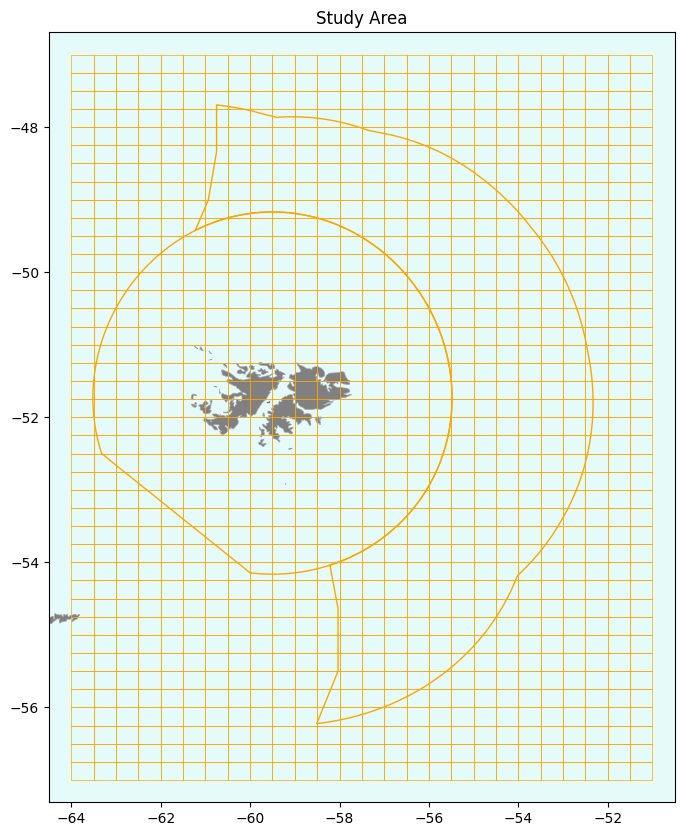

In [52]:
import math
from shapely.geometry import box

# bbox_poly = box(xmin, ymin, xmax, ymax)
# bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326")

# --- Plot --------------------------------------------------------------------

ax = land.plot(color="grey", edgecolor="none", figsize=(10, 10))

ax.set_facecolor("#e5fbfa")

coast.plot(ax=ax, color="darkgrey", linewidth=0.5)
fisheries.plot(ax=ax, edgecolor="orange", color="none", linewidth=0.5)
limits.plot(ax=ax, edgecolor="orange", color="none", linewidth=1)

# bbox_gdf.boundary.plot(ax=ax, edgecolor="red", linewidth=1)

mid_lat = (ymin + ymax) / 2

scale = math.cos(math.radians(mid_lat))

ax.set_xlim(xmin - margin, xmax + margin)

ax.set_ylim(ymin - margin * scale, ymax + margin * scale)

ax.set_title("Study Area")
# ax.set_aspect("equal")
